## View NPZ file

File: larger_test__S2A_MSIL2A_20250612T103701_N0511_R008_20250612T124517__S1A_IW_GRDH_1SDV_20250612T170127_20250612T170152_059616_0766D2_136C.SAFE_r4736_c4224.npz
Shapes: s1 (2, 128, 128) s2 (11, 128, 128) valid (128, 128)
s2_pass: S2A_MSIL2A_20250612T103701_N0511_R008_20250612T124517
s2 tile count: 4


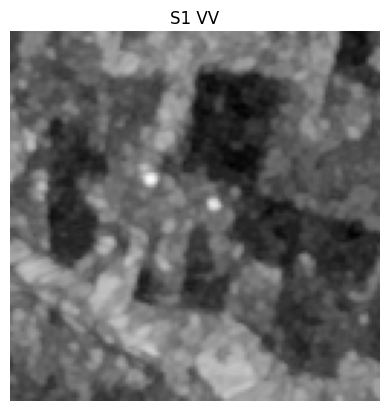

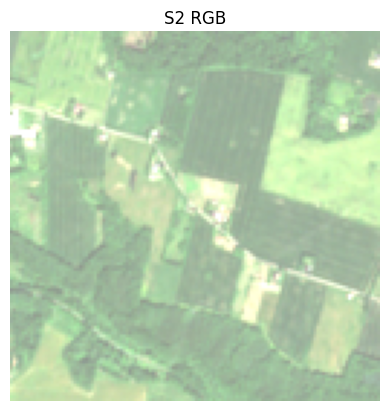

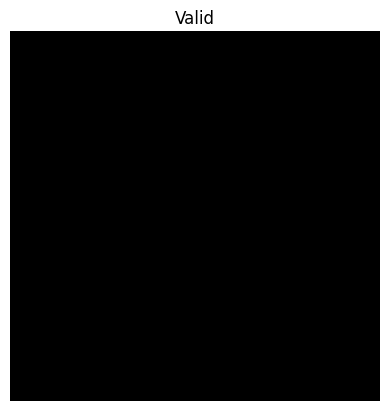

In [ ]:
import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

NPZ_DIR = Path('/home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/tiles_npz')
npz_files = sorted(NPZ_DIR.glob('*.npz'))
if not npz_files:
    raise FileNotFoundError(f'No NPZ files in {NPZ_DIR}')

p = npz_files[0]
d = np.load(p, allow_pickle=True)
meta = json.loads(str(d['meta']))

# Handles both formats:
# per_pass: s1=(N,2,H,W), s2=(N,11,H,W), valid=(N,H,W)
# per_patch: s1=(2,H,W), s2=(11,H,W), valid=(H,W)
i = 0
if d['s1'].ndim == 4:
    s1 = d['s1'][i, 0]
    s2 = d['s2'][i]
    valid = d['valid'][i]
else:
    s1 = d['s1'][0]
    s2 = d['s2']
    valid = d['valid']

rgb = np.stack([s2[3], s2[2], s2[1]], axis=-1)  # B04,B03,B02
p98 = np.percentile(rgb[rgb[..., 0] > 0], 98) if np.any(rgb[..., 0] > 0) else 1.0
rgb = np.clip(rgb / (p98 + 1e-9), 0, 1)

print('File:', p.name)
print('Shapes: s1', d['s1'].shape, 's2', d['s2'].shape, 'valid', d['valid'].shape)
print('s2_pass:', meta.get('s2_pass'))
print('s2 tile count:', len(meta.get('s2_tiles', [])))

plt.figure(); plt.title('S1 VV'); plt.imshow(s1, cmap='gray'); plt.axis('off')
plt.figure(); plt.title('S2 RGB'); plt.imshow(rgb); plt.axis('off')
plt.figure(); plt.title('Valid'); plt.imshow(valid, cmap='gray'); plt.axis('off')
plt.show()


## Find coordinates of NPZ

In [29]:
import json
from pathlib import Path

import numpy as np
import rasterio
from pyproj import Transformer

NPZ_DIR = Path('/home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/tiles_npz')
npz_path = sorted(NPZ_DIR.glob('*.npz'))[0]
d = np.load(npz_path, allow_pickle=True)
meta = json.loads(str(d['meta']))

# Works for both per_pass and per_patch naming/layouts
job, s2pass, _ = npz_path.stem.split('__', 2)
mosaic_b02 = npz_path.parent.parent / 'mosaic' / f'{job}__{s2pass}__B02.tif'

i = 0
if np.ndim(d['row0']) == 0:
    r0 = int(d['row0'])
    c0 = int(d['col0'])
else:
    r0 = int(d['row0'][i])
    c0 = int(d['col0'][i])

tile = int(meta['tile'])

with rasterio.open(mosaic_b02) as ds:
    rc = r0 + tile / 2
    cc = c0 + tile / 2
    x, y = ds.xy(rc, cc)
    to_wgs84 = Transformer.from_crs(ds.crs, 'EPSG:4326', always_xy=True)
    lon, lat = to_wgs84.transform(x, y)

print(f'Patch center: lat={lat:.6f}, lon={lon:.6f}')
print('Mosaic CRS:', ds.crs)


Patch center: lat=55.768890, lon=9.462629
Mosaic CRS: EPSG:32632


## View mosaic

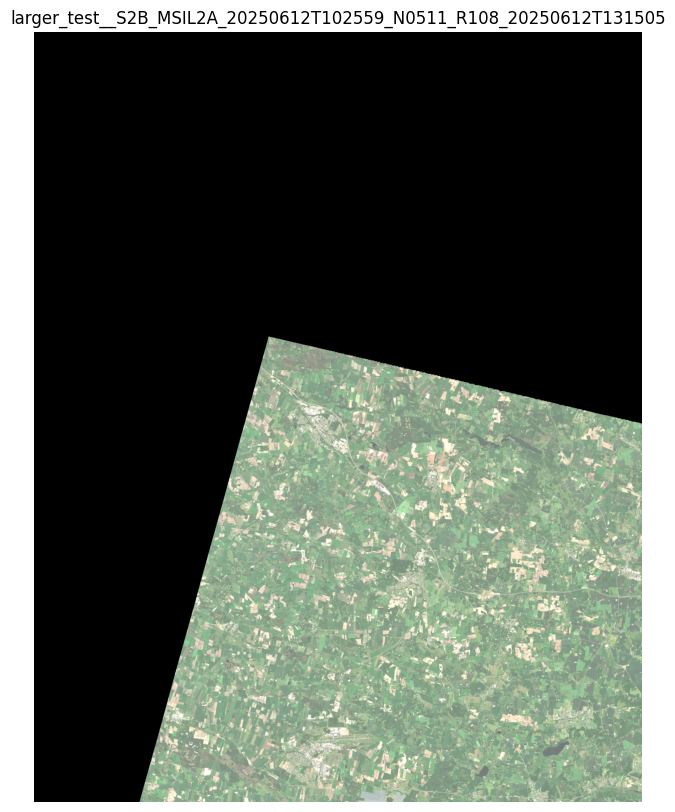

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

mosaic_dir = Path('/home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/mosaic')
b04 = sorted(mosaic_dir.glob('*__B04.tif'))[-1]
stem = b04.name.replace('__B04.tif', '')
b03 = mosaic_dir / f'{stem}__B03.tif'
b02 = mosaic_dir / f'{stem}__B02.tif'

with rasterio.open(b04) as r, rasterio.open(b03) as g, rasterio.open(b02) as b:
    R = r.read(1).astype(np.float32)
    G = g.read(1).astype(np.float32)
    B = b.read(1).astype(np.float32)

rgb = np.stack([R, G, B], axis=-1)
mask = rgb[..., 0] > 0
p98 = np.percentile(rgb[mask], 98) if mask.any() else 1.0
rgb = np.clip(rgb / (p98 + 1e-9), 0, 1)

plt.figure(figsize=(10, 10))
plt.title(stem)
plt.imshow(rgb)
plt.axis('off')
plt.show()


## View raw S2 image

Using SAFE: /home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/raw/S2A_MSIL2A_20250612T103701_N0511_R008_T32UMG_20250612T124517/S2A_MSIL2A_20250612T103701_N0511_R008_T32UMG_20250612T124517.SAFE


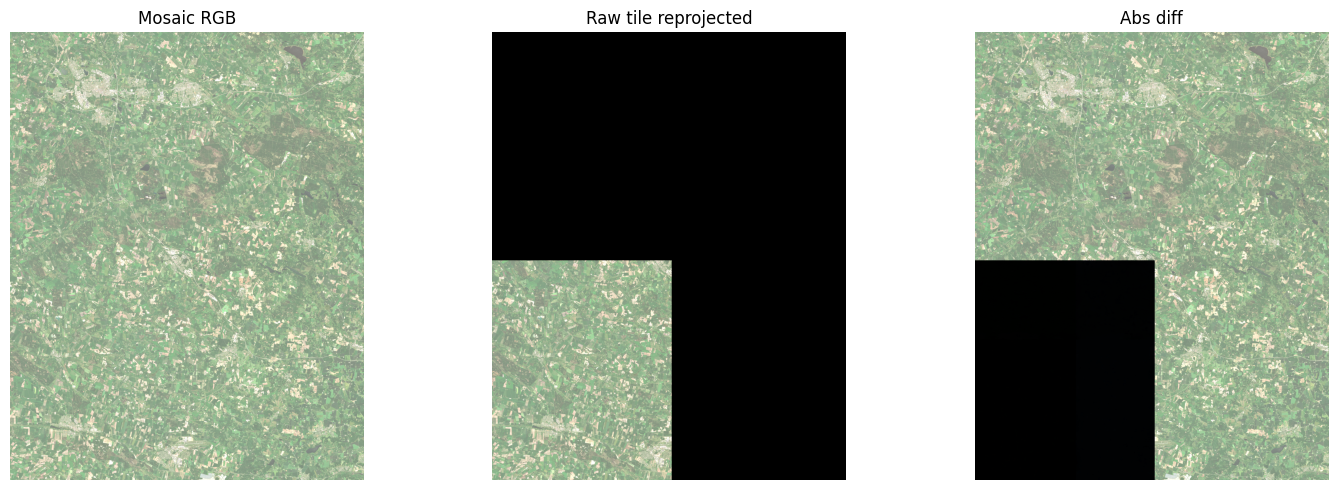

Compared raw SAFE: S2A_MSIL2A_20250612T103701_N0511_R008_T32UMG_20250612T124517.SAFE


In [31]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import Resampling, reproject


def stretch(rgb):
    m = rgb[..., 0] > 0
    p = np.percentile(rgb[m], 98) if np.any(m) else 1.0
    return np.clip(rgb / (p + 1e-9), 0, 1)


npz = sorted(Path('/home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/tiles_npz').glob('*.npz'))[0]
d = np.load(npz, allow_pickle=True)
meta = json.loads(str(d['meta']))

job, s2pass, _ = npz.stem.split('__', 2)

raw_dir = Path('/home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/raw')
tile_name = meta['s2_tiles'][0]
tile_folder = raw_dir / tile_name.replace('.SAFE', '')

safe_candidates = sorted(tile_folder.glob('*.SAFE')) or sorted(tile_folder.glob('**/*.SAFE'))
if not safe_candidates:
    raise FileNotFoundError(f'No SAFE found under {tile_folder}')

safe = safe_candidates[0]
print('Using SAFE:', safe)

r10 = sorted(safe.glob('**/IMG_DATA/R10m'))[0]
r_b04 = sorted(r10.glob('*_B04_10m.jp2'))[0]
r_b03 = sorted(r10.glob('*_B03_10m.jp2'))[0]
r_b02 = sorted(r10.glob('*_B02_10m.jp2'))[0]

mosaic_dir = Path('/home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/mosaic')
m_b04 = mosaic_dir / f'{job}__{s2pass}__B04.tif'
m_b03 = mosaic_dir / f'{job}__{s2pass}__B03.tif'
m_b02 = mosaic_dir / f'{job}__{s2pass}__B02.tif'

with rasterio.open(m_b04) as ref:
    H, W = ref.height, ref.width
    tr, crs = ref.transform, ref.crs

    with rasterio.open(m_b04) as ds:
        M4 = ds.read(1).astype(np.float32)
    with rasterio.open(m_b03) as ds:
        M3 = ds.read(1).astype(np.float32)
    with rasterio.open(m_b02) as ds:
        M2 = ds.read(1).astype(np.float32)
    mosaic_rgb = np.stack([M4, M3, M2], axis=-1)

    R4 = np.zeros((H, W), np.float32)
    R3 = np.zeros((H, W), np.float32)
    R2 = np.zeros((H, W), np.float32)

    with rasterio.open(r_b04) as src:
        reproject(
            rasterio.band(src, 1),
            R4,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=tr,
            dst_crs=crs,
            src_nodata=0,
            dst_nodata=0,
            resampling=Resampling.bilinear,
        )
    with rasterio.open(r_b03) as src:
        reproject(
            rasterio.band(src, 1),
            R3,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=tr,
            dst_crs=crs,
            src_nodata=0,
            dst_nodata=0,
            resampling=Resampling.bilinear,
        )
    with rasterio.open(r_b02) as src:
        reproject(
            rasterio.band(src, 1),
            R2,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=tr,
            dst_crs=crs,
            src_nodata=0,
            dst_nodata=0,
            resampling=Resampling.bilinear,
        )

raw_on_mosaic_rgb = np.stack([R4, R3, R2], axis=-1)

A = stretch(mosaic_rgb)
B = stretch(raw_on_mosaic_rgb)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.title('Mosaic RGB'); plt.imshow(A); plt.axis('off')
plt.subplot(1, 3, 2); plt.title('Raw tile reprojected'); plt.imshow(B); plt.axis('off')
plt.subplot(1, 3, 3); plt.title('Abs diff'); plt.imshow(np.abs(A - B)); plt.axis('off')
plt.tight_layout()
plt.show()

print('Compared raw SAFE:', safe.name)
